

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>









<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


# Sprint 7 - Zuber
## Análise de dados para compreensão de hábito de consumo dos usuários
- Levantamento de dados e hipóteses para encontrar padrões, entender as preferências dos passageiros e o impacto de fatores externos nas corridas.


## Etapa 1 - Importar os dados extraídos via SQL 

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# corridas por empresa de 15 a 16/11/2017
trips_cab = pd.read_csv('/datasets/project_sql_result_01.csv')

In [25]:
print(trips_cab.info())
print(trips_cab.describe())
print(trips_cab.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299


In [26]:
# média de viagens por bairro onde foi finalizada
avg_by_loc = pd.read_csv('/datasets/project_sql_result_04.csv')

In [27]:
print(avg_by_loc.info())
print(avg_by_loc.describe())
print(avg_by_loc.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000


In [28]:
# viagens de Loop para Aeroporto O'Hare com as condições climáticas no início da corrida e a duração dela em segundos
weather = pd.read_csv('/datasets/project_sql_result_07.csv')

In [29]:

print(weather.info())
print(weather.describe())
print(weather.head(20))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
       duration_seconds
count       1068.000000
mean        2071.731273
std          769.461125
min            0.000000
25%         1438.250000
50%         1980.000000
75%         2580.000000
max         7440.000000
               start_ts weather_conditions  duration_seconds
0   2017-11-25 16:00:00               Good            2410.0
1   2017-11-25 14:00:00               Good            1920.0
2   2017-11-25 12:00:00               Good            1543.0
3   2017-11-04 10:00:00               Good            2512.0
4   2017-11-11 07:00:00               Good            1440.0
5   2017-

1. Foi realizado a importação das bibliotecas a serem usadas neste projeto.
2. Foi gerado um DataFrame para cada arquivo, os quais contém os dados brutos a serem trabalhados.
3. Foi utilizado os métodos *.info()*, *.describe()* e *.head()* para realizar a análise inicial dos dados, identificando possíveis tratamentos necessários.


## Etapa 2 - Preparação dos dados

In [30]:
trips_cab['company_name'] = trips_cab['company_name'].str.lower()
trips_cab['company_name'] = trips_cab['company_name'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

print(trips_cab)

                       company_name  trips_amount
0                         flash cab         19558
1         taxi affiliation services         11422
2                 medallion leasing         10367
3                        yellow cab          9888
4   taxi affiliation service yellow          9299
..                              ...           ...
59                   adwar h nikola             7
60                       benny jona             7
61                  sergey cab corp             5
62                      felman corp             3
63                   rc andrews cab             2

[64 rows x 2 columns]


In [31]:
avg_by_loc['dropoff_location_name'] = avg_by_loc['dropoff_location_name'].str.lower()

print(avg_by_loc)

   dropoff_location_name  average_trips
0                   loop   10727.466667
1            river north    9523.666667
2          streeterville    6664.666667
3              west loop    5163.666667
4                 o'hare    2546.900000
..                   ...            ...
89       mount greenwood       3.137931
90             hegewisch       3.117647
91              burnside       2.333333
92             east side       1.961538
93             riverdale       1.800000

[94 rows x 2 columns]


In [32]:


dup_trips = trips_cab.duplicated().sum()
print(f"Número de linhas duplicadas: {dup_trips} | Total de linhas: {len(trips_cab)}")
dup_avg = avg_by_loc.duplicated().sum()
print(f"Número de linhas duplicadas: {dup_avg} | Total de linhas: {len(avg_by_loc)}")
dup_weather = weather.duplicated().sum()
print(f"Número de linhas duplicadas: {dup_weather} | Total de linhas: {len(weather)}")



Número de linhas duplicadas: 0 | Total de linhas: 64
Número de linhas duplicadas: 0 | Total de linhas: 94
Número de linhas duplicadas: 197 | Total de linhas: 1068


In [33]:
if dup_weather > 0:
    print("\nLinhas duplicadas (todas as ocorrências):")
    print(weather[weather.duplicated(keep=False)].to_string())
else:
    print("\nNão há linhas duplicadas para exibir.")


Linhas duplicadas (todas as ocorrências):
                 start_ts weather_conditions  duration_seconds
4     2017-11-11 07:00:00               Good            1440.0
8     2017-11-11 14:00:00               Good            2460.0
10    2017-11-18 06:00:00               Good            1500.0
16    2017-11-04 12:00:00               Good            2640.0
23    2017-11-04 14:00:00               Good            3360.0
24    2017-11-04 14:00:00               Good            3180.0
33    2017-11-04 12:00:00               Good            2580.0
35    2017-11-11 09:00:00               Good            1620.0
43    2017-11-11 06:00:00               Good            1260.0
50    2017-11-11 12:00:00               Good            1980.0
51    2017-11-04 16:00:00                Bad            2760.0
53    2017-11-25 12:00:00               Good            1380.0
54    2017-11-18 10:00:00                Bad            1440.0
60    2017-11-11 08:00:00               Good            1320.0
61    2017-1

In [34]:
weather['start_ts'] = pd.to_datetime(weather['start_ts'])
weather['date'] = weather['start_ts'].dt.date
weather['start_hour'] = weather['start_ts'].dt.hour
weather = weather.drop('start_ts', axis=1)
weather["duration_seconds"] = weather["duration_seconds"].astype("int64")

In [35]:
print(weather.head())
print(weather.info())

  weather_conditions  duration_seconds        date  start_hour
0               Good              2410  2017-11-25          16
1               Good              1920  2017-11-25          14
2               Good              1543  2017-11-25          12
3               Good              2512  2017-11-04          10
4               Good              1440  2017-11-11           7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   weather_conditions  1068 non-null   object
 1   duration_seconds    1068 non-null   int64 
 2   date                1068 non-null   object
 3   start_hour          1068 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 33.5+ KB
None


A respeito dos preparos realizados nos dados:
- Transformado a coluna *duration_seconds* do df *weather* em números inteiros.
- Foi aplicado o <.str.lower()> para padronização e no df **trips_cab** também foi aplicado a remoção de caracrteres diferentes e números para 
- Sobre valores duplicados, o df *weather* possui 197 linhas duplicadas. Contudo, após observá-los, foi decidido mantê-los pois há a possibilidade de serem corridas de táxis diferentes, no mesmo dia e horário, que realizaram o percurso semelhante com a mesma duração de tempo.
- A data e a hora do df *weather* são de extrema importância para a análise, pois determinam os horários e dias com clima ruim. Por esse motivo, foi transformado a coluna *start_ts* nas colunas *date* e *start_hour*

## Etapa 3 - Análise dos dados

### 1. Identificar os 10 principais bairros em termos de destinos

In [36]:
top_10_dropoff = avg_by_loc.sort_values('average_trips', ascending=False).head(10)

print("Top 10 Bairros Destino por Média de Corridas:")
print(top_10_dropoff)


Top 10 Bairros Destino por Média de Corridas:
  dropoff_location_name  average_trips
0                  loop   10727.466667
1           river north    9523.666667
2         streeterville    6664.666667
3             west loop    5163.666667
4                o'hare    2546.900000
5             lake view    2420.966667
6            grant park    2068.533333
7         museum campus    1510.000000
8            gold coast    1364.233333
9    sheffield & depaul    1259.766667


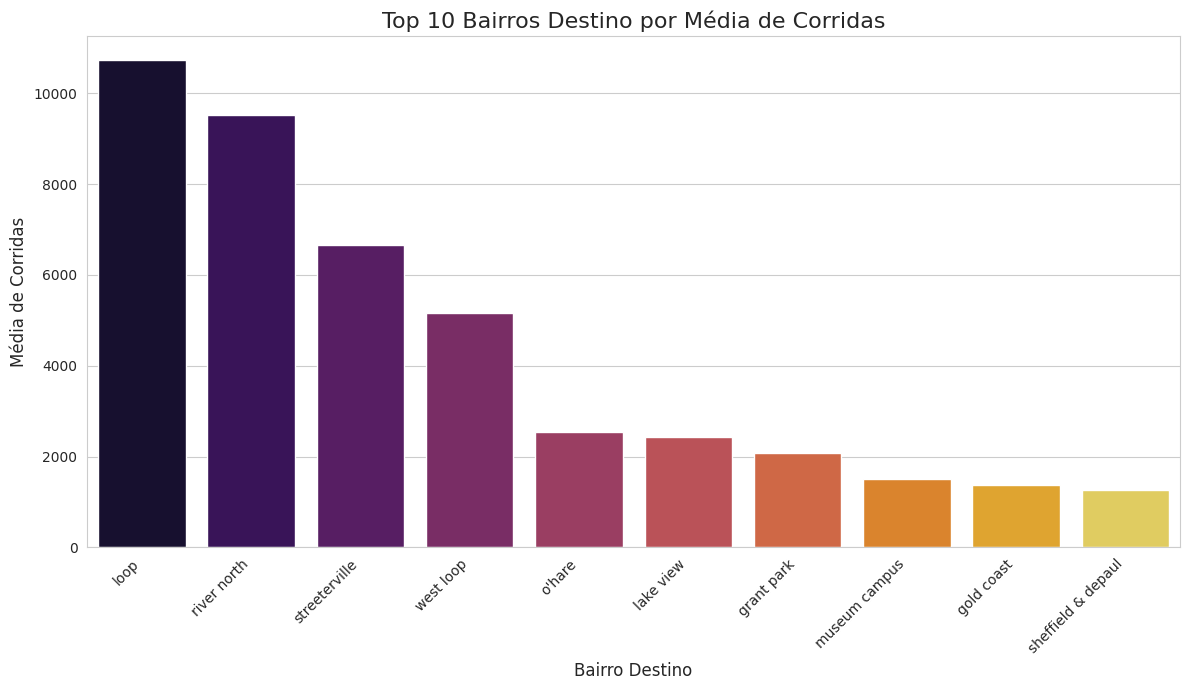

In [37]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 7))

sns.barplot(x='dropoff_location_name', y='average_trips', data=top_10_dropoff, palette='inferno')


plt.title('Top 10 Bairros Destino por Média de Corridas', fontsize=16)
plt.xlabel('Bairro Destino', fontsize=12)
plt.ylabel('Média de Corridas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Diante do top 10 da média das corridas por bairro, nota-se a presença de destaque do bairro *Loop* como principal destino das corridas, seguido de *River North* e *Streeterville*, sendo que, esse último, tem uma diferença em torno de 4 mil e 3 mil do primeiro e do segundo, respectivamente.


### 2. Identificar as empresas de taxi e o número de corridas

In [38]:
sorted_trips = trips_cab.sort_values('trips_amount', ascending=False)
print(sorted_trips)

                       company_name  trips_amount
0                         flash cab         19558
1         taxi affiliation services         11422
2                 medallion leasing         10367
3                        yellow cab          9888
4   taxi affiliation service yellow          9299
..                              ...           ...
59                   adwar h nikola             7
60                       benny jona             7
61                  sergey cab corp             5
62                      felman corp             3
63                   rc andrews cab             2

[64 rows x 2 columns]


Diante da quantidade de empresas de táxi, foi escolhido somar e unificar as que possuem viagens abaixo de 1000 para serem unificadas como *others*, visando otimizar a distribuição do gráfico e melhorar sua visualização e interpretação. 
Entende-se que essas empresas têm pouca relevância na análise individual das companhias.

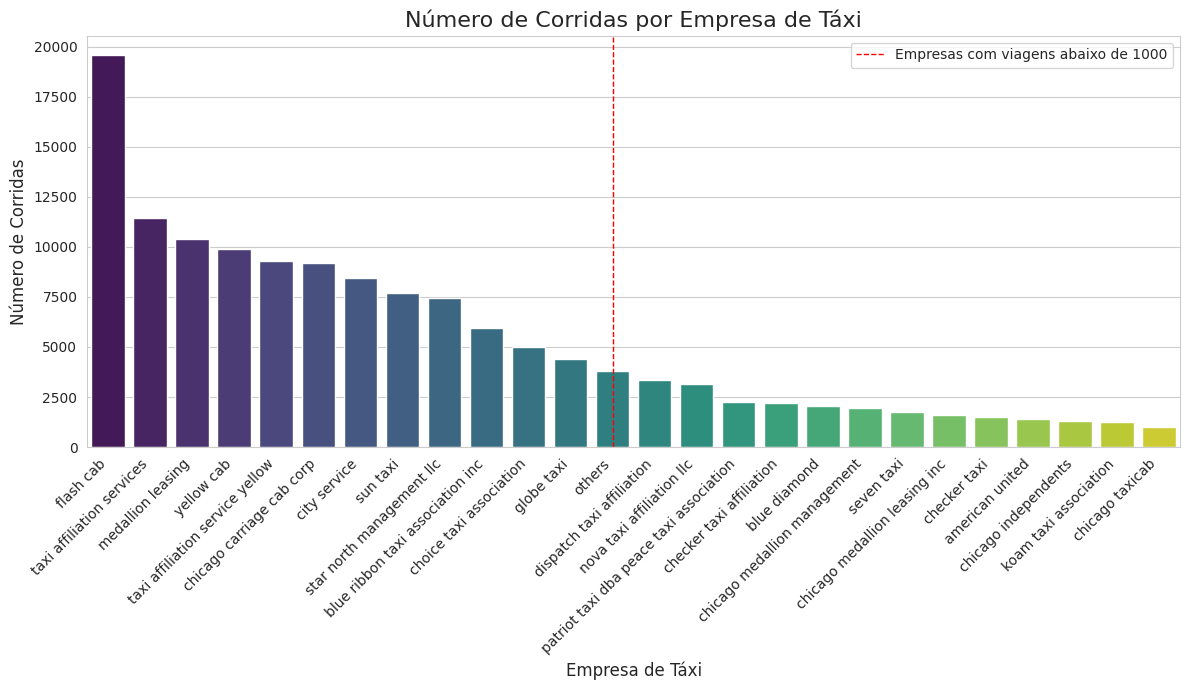

In [39]:
threshold = 1000
large_companies = trips_cab[trips_cab['trips_amount'] >= threshold]
small_companies = trips_cab[trips_cab['trips_amount'] < threshold]

if not small_companies.empty:
    others_trips_amount = small_companies['trips_amount'].sum()
    others_row = pd.DataFrame([{'company_name': 'others', 'trips_amount': others_trips_amount}])
    trips_cab_grouped = pd.concat([large_companies, others_row], ignore_index=True)
else:
    trips_cab_grouped = large_companies.copy()

trips_cab_grouped = trips_cab_grouped.sort_values(by='trips_amount', ascending=False)
trips_cab_grouped = trips_cab_grouped.reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.barplot(x='company_name', y='trips_amount', data=trips_cab_grouped, palette='viridis')

plt.title('Número de Corridas por Empresa de Táxi', fontsize=16)
plt.xlabel('Empresa de Táxi', fontsize=12)
plt.ylabel('Número de Corridas', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

if 'others' in trips_cab_grouped['company_name'].values:
    others_position = trips_cab_grouped[trips_cab_grouped['company_name'] == 'others'].index[0]
    plt.axvline(x=others_position, color='red', linestyle='--', linewidth=1, label='Empresas com viagens abaixo de 1000')
    plt.legend()

plt.show()

Nota-se que a empresa *flash cab* destaca-se sendo a mais utilizada com o segundo lugar tendo um pouco mais que a metade das suas corridas.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Ambas as visualizações foram implementadas conforme o solicitado e permitem ver com clareza os itens que se destacam em cada uma das dimensões.
</div>

## Etapa 4 - Teste de hipóteses
A partir do df *weather*, realizar os testes de hipóteses.

### Teste de Hipótese:

**Afirmação a ser testada:** A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos.

- A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare não muda nos sábados chuvosos. Em outras palavras, a duração média dos passeios em sábados chuvosos é igual à duração média dos passeios em sábados não chuvosos.
(μ_chuvoso = μ_nao_chuvoso)
- H₁: A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos. Ou seja, a duração média dos passeios em sábados chuvosos é diferente da duração média dos passeios em sábados não chuvosos.
(μ_chuvoso ≠ μ_nao_chuvoso)
- Foi definido α = 0.05 ou 5% para o *p-value*.

In [40]:
print("\nPrimeiras 5 linhas do DataFrame 'weather' (dados para o teste):")
print(weather.head())


Primeiras 5 linhas do DataFrame 'weather' (dados para o teste):
  weather_conditions  duration_seconds        date  start_hour
0               Good              2410  2017-11-25          16
1               Good              1920  2017-11-25          14
2               Good              1543  2017-11-25          12
3               Good              2512  2017-11-04          10
4               Good              1440  2017-11-11           7


Para o teste, foi escolhido como hipótese nula (H₀) o cenário no qual as condições se igualam, ou seja, que a duração média de Loop para O'Hare não muda em sábados chuvosos. Já como hipótese alternativa (H₁), foi definida como contrária a essas condições, ou seja, a duração média muda ao chover. Além disso, foi determinado como valor alfa (α) 5%, ou 0,05, por ser o valor padrão mais aceito e comumente utilizado para avaliar o p-value.

In [41]:
duration_chuvoso = weather[weather['weather_conditions'] == 'Bad']['duration_seconds']
duration_nao_chuvoso = weather[weather['weather_conditions'] == 'Good']['duration_seconds']

print(f"Número de viagens em sábados chuvosos: {len(duration_chuvoso)}")
print(f"Número de viagens em sábados não chuvosos: {len(duration_nao_chuvoso)}")

if len(duration_chuvoso) < 2 or len(duration_nao_chuvoso) < 2:
    print("Não há dados suficientes em um ou ambos os grupos para realizar o teste t.")
else:
    statistic, p_value = stats.ttest_ind(duration_chuvoso, duration_nao_chuvoso, equal_var=False)

    print(f"\nEstatística t: {statistic:.3f}")
    print(f"Valor p: {p_value:.3f}")

    alpha = 0.05

    print(f"Nível de significância (alpha): {alpha}")

    if p_value < alpha:
        print("\nResultado: Rejeitamos a hipótese nula (H₀).")
        print("Conclusão: Há evidências estatísticas de que a duração média dos passeios do Loop para O'Hare muda nos sábados chuvosos.")
    else:
        print("\nResultado: Não rejeitamos a hipótese nula (H₀).")
        print("Conclusão: Não há evidências estatísticas suficientes para afirmar que a duração média dos passeios do Loop para O'Hare muda nos sábados chuvosos.")


Número de viagens em sábados chuvosos: 180
Número de viagens em sábados não chuvosos: 888

Estatística t: 7.186
Valor p: 0.000
Nível de significância (alpha): 0.05

Resultado: Rejeitamos a hipótese nula (H₀).
Conclusão: Há evidências estatísticas de que a duração média dos passeios do Loop para O'Hare muda nos sábados chuvosos.



<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

O teste foi formulado, implementado e analisado corretamente. Muito bom!
</div>



## Etapa 5 - Conclusão Geral

O presente projeto de análise de dados teve como objetivo principal compreender os padrões de consumo dos usuários de táxi e o impacto de fatores externos nas corridas, utilizando os DataFrames **avg_by_loc**, **trips_cab** e **weather**. 

Após a importação e uma análise inicial dos dados, que incluiu a identificação de possíveis tratamentos, procedeu-se à preparação dos mesmos: 
- A coluna *duration_seconds* do DataFrame **weather** foi convertida para inteiros.
- A padronização de texto foi aplicada nas colunas *company_name* (do **trips_cab**) e *weather_conditions* (do **weather**), com remoção de caracteres especiais e números.
- As 197 linhas duplicadas no DataFrame **weather** foram mantidas, sob a premissa de que poderiam representar corridas distintas ocorrendo simultaneamente.
- Além disso, a coluna *start_ts* do **weather** foi segmentada em *date* e *start_hour* para facilitar análises temporais.

Na fase de análise, ao realizar o ranking de destinos, o bairro *Loop* destacou-se como o principal destino das corridas, seguido por *River North* e *Streeterville*, evidenciando uma clara preferência dos passageiros. 
Já em relação às empresas de táxi, aquelas com menos de 1000 corridas foram agrupadas como *others* para otimizar a clareza do gráfico, revelando a *Flash Cab* como a empresa líder em número de viagens. 

Por fim, no teste de hipóteses, formulou-se que a duração média dos passeios do Loop para O'Hare muda nos sábados chuvosos (H₁) versus a hipótese nula de que não há mudança (H₀), com um nível de significância de 5%. Os resultados indicaram um valor p de 0.000, levando à rejeição da hipótese nula e confirmando que as condições climáticas de chuva/tempestade em sábados têm um impacto estatisticamente significativo na duração média dessas viagens.